In [31]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Classification Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report
)

In [32]:
df = pd.read_csv('Rent.csv')

In [33]:
df.head()

,BHK,Rent,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
0,2,10000.0,1100.000000,454,220,4,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,20000.0,967.936049,14,1525,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,17000.0,1000.000000,14,1758,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2,10000.0,967.936049,10,525,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2,7500.0,850.000000,10,1888,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [34]:
df.shape

(4727, 19)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4727 entries, 0 to 4726
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHK            4727 non-null   int64  
 1   Rent           4727 non-null   float64
 2   Size           4727 non-null   float64
 3   Floor          4727 non-null   int64  
 4   Area Locality  4727 non-null   int64  
 5   City           4727 non-null   int64  
 6   Bathroom       4727 non-null   float64
 7   N_11           4727 non-null   float64
 8   N_12           4727 non-null   float64
 9   N_13           4727 non-null   float64
 10  N_14           4727 non-null   float64
 11  N_15           4727 non-null   float64
 12  N_16           4727 non-null   float64
 13  N_17           4727 non-null   float64
 14  N_18           4727 non-null   float64
 15  N_19           4727 non-null   float64
 16  N_20           4727 non-null   float64
 17  N_21           4727 non-null   float64
 18  N_22    

In [36]:
df.isnull().sum()

BHK              0
Rent             0
Size             0
Floor            0
Area Locality    0
City             0
Bathroom         0
N_11             0
N_12             0
N_13             0
N_14             0
N_15             0
N_16             0
N_17             0
N_18             0
N_19             0
N_20             0
N_21             0
N_22             0
dtype: int64

In [37]:
X = df.drop('Rent', axis=1)

y = df['Rent']

In [38]:
df.drop_duplicates(inplace=True)

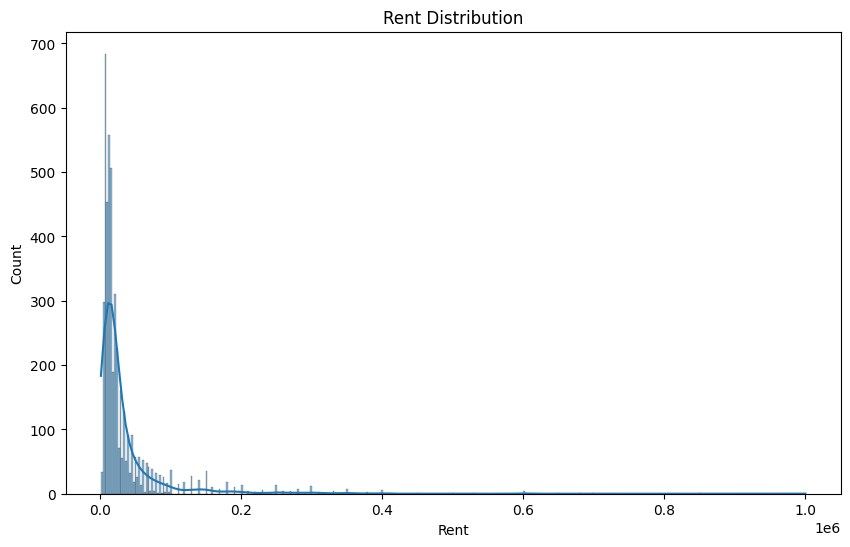

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(df['Rent'], kde=True)

plt.title('Rent Distribution')

plt.show()

In [40]:
Q1 = df['Rent'].quantile(0.25)

Q3 = df['Rent'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df['Rent'] >= lower) &
    (df['Rent'] <= upper)
]

In [41]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    
    df[col] = le.fit_transform(df[col])

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [44]:
knn_reg = KNeighborsRegressor(n_neighbors=3)

knn_reg.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [45]:
y_pred_knn = knn_reg.predict(X_test)

In [46]:
print("KNN R2 Score :")

print(r2_score(y_test, y_pred_knn))

KNN R2 Score :
0.5538346902048837


In [47]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
y_pred_lin = lin_reg.predict(X_test)

In [49]:
print("Linear Regression R2 Score :")

print(r2_score(y_test, y_pred_lin))

Linear Regression R2 Score :
0.500296446993888


In [50]:
svr = SVR(kernel='rbf')

svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [51]:
y_pred_svr = svr.predict(X_test)

In [52]:
print("SVR R2 Score :")

print(r2_score(y_test, y_pred_svr))

SVR R2 Score :
-0.10237686268524371


In [53]:
reg_models = pd.DataFrame({

    'Model': [
        'KNN Regressor',
        'Linear Regression',
        'SVR'
    ],

    'R2 Score': [

        r2_score(y_test, y_pred_knn),

        r2_score(y_test, y_pred_lin),

        r2_score(y_test, y_pred_svr)
    ]
})

reg_models

,Model,R2 Score
0,KNN Regressor,0.553835
1,Linear Regression,0.500296
2,SVR,-0.102377


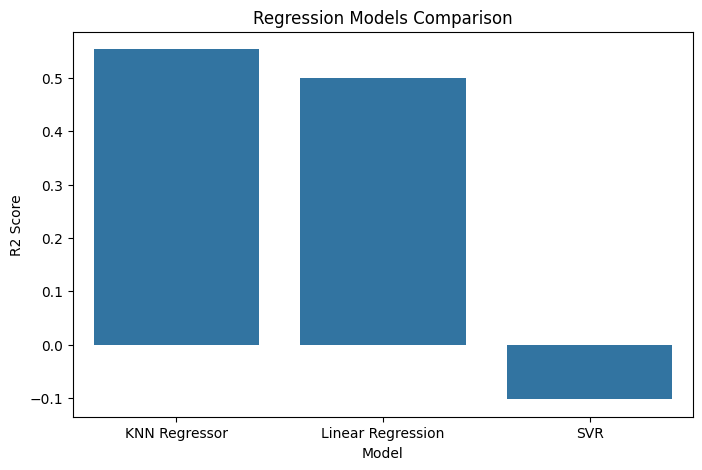

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=reg_models
)

plt.title('Regression Models Comparison')

plt.show()

In [55]:
bins = [0, 10000, 30000, 60000, 200000]

labels = ['Low', 'Medium', 'High', 'Luxury']

df['Rent_Category'] = pd.cut(
    df['Rent'],
    bins=bins,
    labels=labels
)

In [56]:
df['Rent_Category'].value_counts()

Rent_Category
Medium    2171
Low       1321
High       667
Luxury      53
Name: count, dtype: int64

In [57]:
X_cls = df.drop(['Rent', 'Rent_Category'], axis=1)

y_cls = df['Rent_Category']

In [58]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

In [59]:
scaler = StandardScaler()

X_train_cls = scaler.fit_transform(X_train_cls)

X_test_cls = scaler.transform(X_test_cls)

In [60]:
knn_cls = KNeighborsClassifier(n_neighbors=5)

knn_cls.fit(X_train_cls, y_train_cls)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
y_pred_knn_cls = knn_cls.predict(X_test_cls)

In [62]:
print("KNN Accuracy :")

print(accuracy_score(y_test_cls, y_pred_knn_cls))

KNN Accuracy :
0.6666666666666666


In [63]:
nb = GaussianNB()

nb.fit(X_train_cls, y_train_cls)

,priors,None
,var_smoothing,1e-09


In [64]:
y_pred_nb = nb.predict(X_test_cls)

In [65]:
print("Naive Bayes Accuracy :")

print(accuracy_score(y_test_cls, y_pred_nb))

Naive Bayes Accuracy :
0.10083036773428232


In [66]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_cls, y_train_cls)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
y_pred_log = log_model.predict(X_test_cls)

In [68]:
print("Logistic Regression Accuracy :")

print(accuracy_score(y_test_cls, y_pred_log))

Logistic Regression Accuracy :
0.6963226571767497


In [69]:
svm_cls = SVC(kernel='rbf')

svm_cls.fit(X_train_cls, y_train_cls)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [70]:
y_pred_svm = svm_cls.predict(X_test_cls)

In [71]:
print("SVM Accuracy :")

print(accuracy_score(y_test_cls, y_pred_svm))

SVM Accuracy :
0.708185053380783


In [72]:
cls_models = pd.DataFrame({

    'Model': [
        'KNN',
        'Naive Bayes',
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [

        accuracy_score(y_test_cls, y_pred_knn_cls),

        accuracy_score(y_test_cls, y_pred_nb),

        accuracy_score(y_test_cls, y_pred_log),

        accuracy_score(y_test_cls, y_pred_svm)
    ]
})

cls_models

,Model,Accuracy
0,KNN,0.666667
1,Naive Bayes,0.100830
2,Logistic Regression,0.696323
3,SVM,0.708185


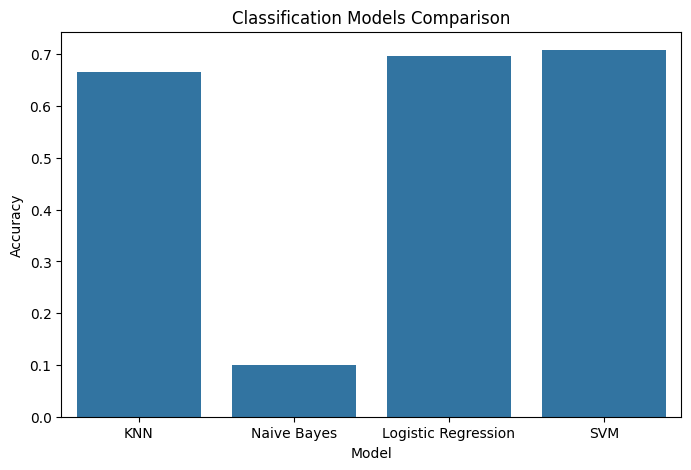

In [73]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=cls_models
)

plt.title('Classification Models Comparison')

plt.show()